## Imports

In [111]:
%load_ext autoreload
%autoreload 2

import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import msml610_utils as ut
import L09_01_reasoning_over_time_utils as time_ut

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO:msml610_utils:Setting notebook style
INFO:msml610_utils:Notebook signature
INFO:msml610_utils:numpy version=1.26.4
INFO:msml610_utils:pymc version=5.18.2
INFO:msml610_utils:matplotlib version=3.10.3
INFO:msml610_utils:arviz version=0.21.0
INFO:msml610_utils:preliz version=0.19.0


Python 3.12.3
Linux 589569fe8102 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [112]:
import helpers.hio as hio

import os

dst_dir = "figures"
hio.create_dir(dst_dir, incremental=True)
# cp msml610/tutorials/figures/*.png msml610/lectures_source/figures

# Cell 1: Estimating Body Weight

## Cell 1.1: Ground truth

In [113]:
n_samples = 12

# We assume we know the real weight.
ground_truth = 160.0 + np.arange(0, n_samples)

# This is what we measure.
measured_weights = np.array(
    [
        158.0,
        164.2,
        160.3,
        159.9,
        162.1,
        164.6,
        169.6,
        167.4,
        166.4,
        171.0,
        171.2,
        172.6,
    ]
)

idx = pd.date_range("2011-01-01", periods=len(measured_weights))
df = pd.DataFrame(measured_weights.T, index=idx, columns=["measurements"])
df["ground_truth"] = ground_truth

df.head()

,measurements,ground_truth
2011-01-01,158.0,160.0
2011-01-02,164.2,161.0
2011-01-03,160.3,162.0
2011-01-04,159.9,163.0
2011-01-05,162.1,164.0


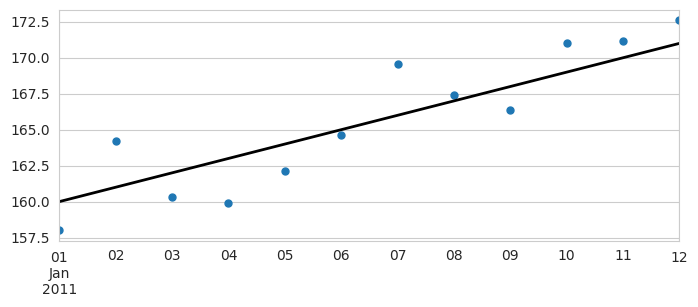

In [114]:
df["measurements"].plot(marker=".", markersize=10, linestyle="None");
df["ground_truth"].plot(color="k", linewidth=2);

plt.savefig(os.path.join(dst_dir, "L09_04_ground_truth.png"))

## Cell 1.2: Knowing gain_rate

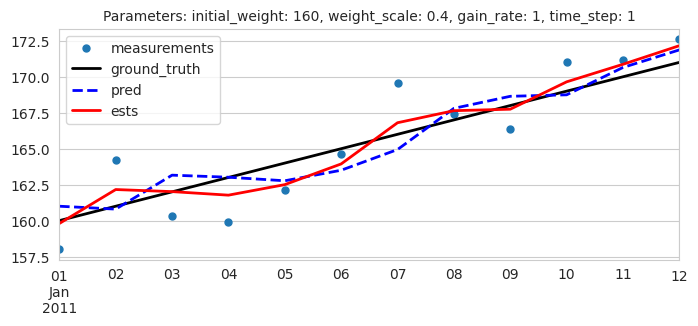

In [130]:
time_ut.cell_1_2_knowning_gain_rate(measured_weights, ground_truth, dst_dir)

## Cell 1.3: Wrong guess of gain_rate

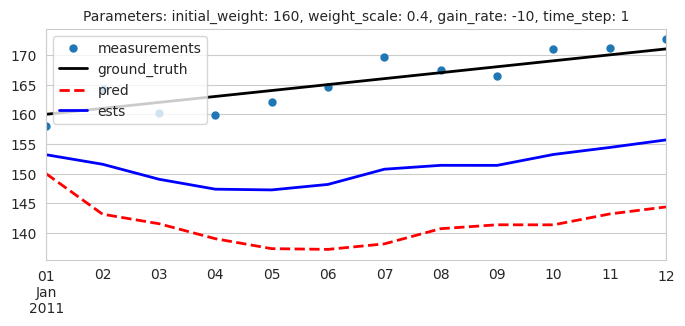

In [116]:
time_ut.cell_1_3_wrong_guess_gain_rate(measured_weights, ground_truth, dst_dir)

## Cell 1.4: Interactive

In [117]:
# Interactive exploration of gain rate parameters.
time_ut.create_interactive_gain_rate_widget(measured_weights, ground_truth)

## Cell 1.5: Learning gain_rate

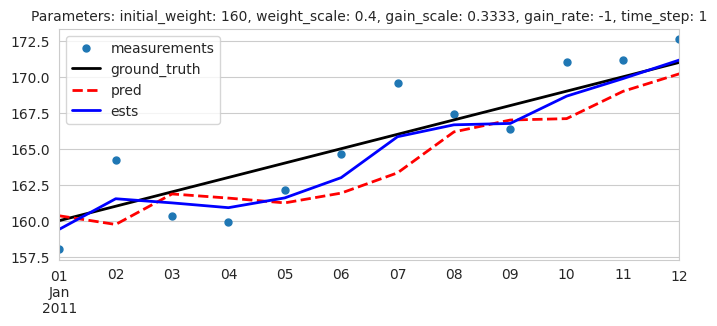

In [118]:
time_ut.cell_1_5_learning_gain_rate(measured_weights, ground_truth, dst_dir)

# Cell 2: g-h Filter on Noisy measurements

## Cell 2.1: Interactive Linear Noisy Data

In [119]:
# Interactive exploration of linear noisy data generation parameters.
time_ut.create_interactive_linear_noisy_data_widget()

## Cell 2.2: Correct Initial Guess

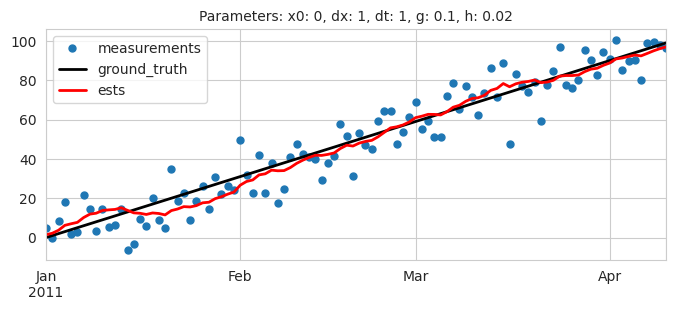

In [133]:
# Demonstrate g-h filter with correct initial guesses.
time_ut.cell_2_2_correct_initial_guess()

## Cell 2.3: Wrong Initial Guess

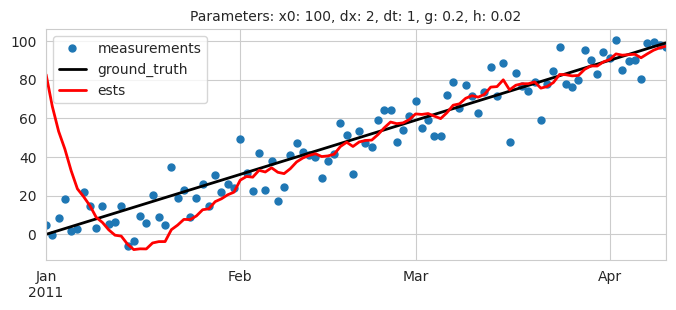

In [134]:
# Demonstrate g-h filter with wrong initial guesses.
time_ut.cell_2_3_wrong_initial_guess()

## Cell 2.4: Extreme Noise

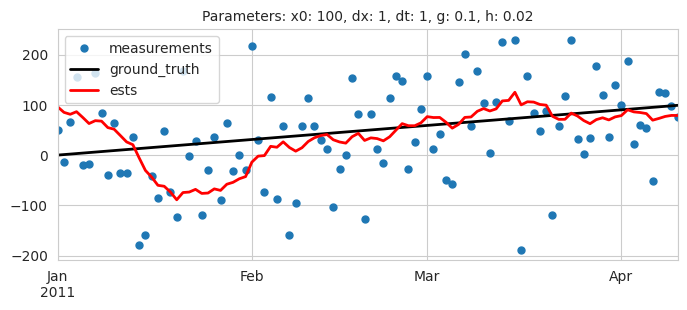

In [135]:
# Demonstrate g-h filter performance with extreme noise.
time_ut.cell_2_4_extreme_noise()

## Cell 2.5: Interactive Non-Linear Noisy Data

In [123]:
# Interactive exploration of non-linear noisy data generation parameters.
time_ut.create_interactive_non_linear_noisy_data_widget()

## Cell 2.6: Non-Linear with g-h Filter

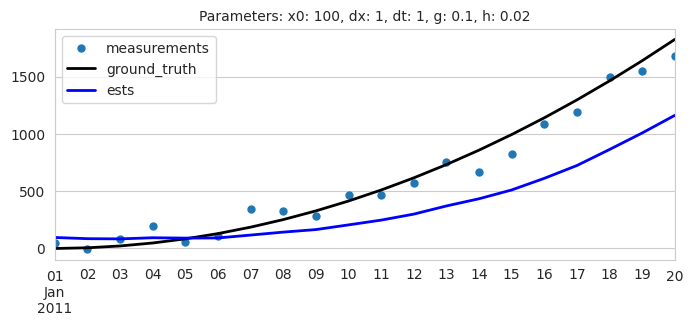

In [124]:
# Demonstrate g-h filter on non-linear data.
time_ut.cell_2_6_non_linear_gh_filter()

## Varying g

<Axes: >

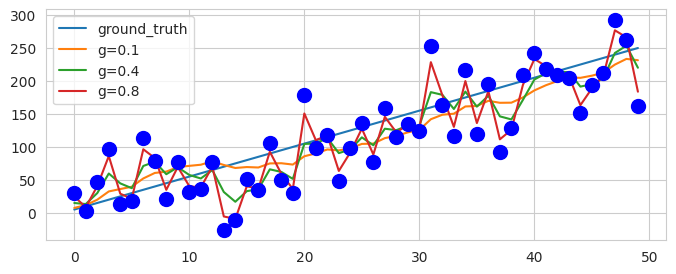

In [125]:
# If g is smaller we follow more our model than the measurements.
# If g is larger we follow more the measurements than our model
# If g is too large we follow the measurements and reject no noise.
np.random.seed(100)
zs, ground_truty = time_ut.gen_linear_noisy_data(
    x0=5, dx=5, count=50, noise_factor=50
)
df = pd.DataFrame(zs)
df.columns = ["measures"]

df["ground_truth"] = ground_truty
df["g=0.1"] = time_ut.gh_filter(data=zs, x0=0.0, dx=5.0, dt=1.0, g=0.1, h=0.01)
df["g=0.4"] = time_ut.gh_filter(data=zs, x0=0.0, dx=5.0, dt=1.0, g=0.4, h=0.01)
df["g=0.8"] = time_ut.gh_filter(data=zs, x0=0.0, dx=5.0, dt=1.0, g=0.8, h=0.01)

df.drop("measures", axis=1).plot()
df["measures"].plot(
    marker="o",
    markersize=10,
    color="b",
    # Hide line.
    linestyle="None",
)

<Axes: >

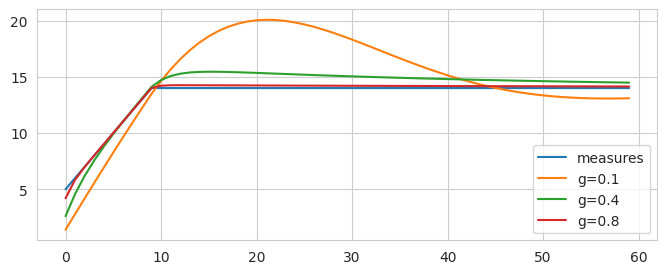

In [126]:
# If g is large we follow more the measures than our model.
zs = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
for i in range(50):
    zs.append(14)
df = pd.DataFrame(zs)
df.columns = ["measures"]

df["g=0.1"] = time_ut.gh_filter(data=zs, x0=0.0, dx=1, dt=1.0, g=0.1, h=0.01)
df["g=0.4"] = time_ut.gh_filter(data=zs, x0=0.0, dx=1, dt=1.0, g=0.4, h=0.01)
df["g=0.8"] = time_ut.gh_filter(data=zs, x0=0.0, dx=1, dt=1.0, g=0.8, h=0.01)

df.plot()

## Varying h
- h affects how much we favor the measurement of $\frac{dx}{dt}$ vs our prediction
- If the signal is varying a lot, then we will react to the transient rapidly

<Axes: >

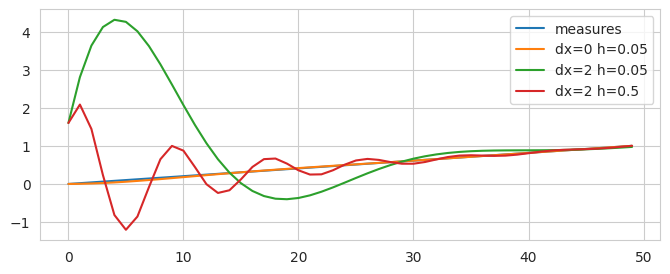

In [127]:
# Go from 0 to 1 in 50 steps (dx = 1 / 50 = 0.02) without noise.
zs = np.linspace(0, 1, 50)
df = pd.DataFrame(zs)
df.columns = ["measures"]

# dx is close to ground truth with small h.
# We track the signal right.
df["dx=0 h=0.05"] = time_ut.gh_filter(data=zs, x0=0, dx=0, dt=1.0, g=0.2, h=0.05)

# dx is wrong, with small h.
# There is big ringing, and we adapt slowly (lower frequency).
df["dx=2 h=0.05"] = time_ut.gh_filter(data=zs, x0=0, dx=2, dt=1.0, g=0.2, h=0.05)

# dx is wrong, with large h.
# Small ringing with higher frequency.
df["dx=2 h=0.5"] = time_ut.gh_filter(data=zs, x0=0, dx=2, dt=1.0, g=0.2, h=0.5)

df.plot()

# Interactice example

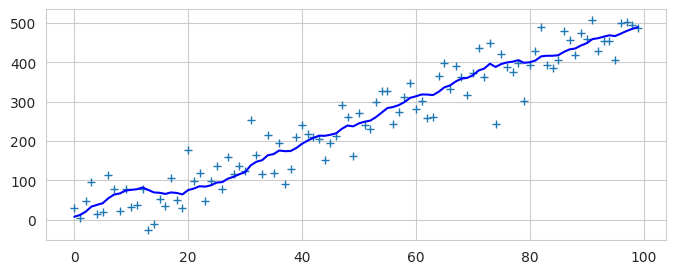

In [128]:
zs1, _ = time_ut.gen_linear_noisy_data(x0=5, dx=5, count=100, noise_factor=50)

fig = None


def interactive_gh(x, dx, g, h):
    global fig
    if fig is not None:
        plt.close(fig)
    fig = plt.figure()
    data = time_ut.gh_filter(data=zs1, x0=x, dx=dx, g=g, h=h)
    plt.scatter(list(range(len(zs1))), zs1, marker="+", lw=1)
    plt.plot(data, color="b")


interactive_gh(0, 5, 0.1, 0.02)

In [129]:
from ipywidgets import interact, FloatSlider

interact(
    interactive_gh,
    x=FloatSlider(value=0.0, min=-200, max=2000, continuous_update=False),
    dx=FloatSlider(value=5.0, min=-50.0, max=50, continuous_update=False),
    g=FloatSlider(
        value=0.1, min=0.01, max=2, step=0.02, continuous_update=False
    ),
    h=FloatSlider(
        value=0.02, min=0.0, max=0.5, step=0.01, continuous_update=False
    ),
)

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='x', max=2000.0, min=-200.0)…

<function __main__.interactive_gh(x, dx, g, h)>